Checking analysis for EZ039 on 230423
All_crit= 0.1455981941309255, 129, 886
Number of cells with |beta| > 0.1: 87 out of 129
Number of cells with 0.5 <= tau <= 1 and |beta| > 0.1: 13
Number of cells with 1 < tau < 2 and |beta| > 0.1: 21
Number of cells with 2 <= tau < 5 and |beta| > 0.1: 30


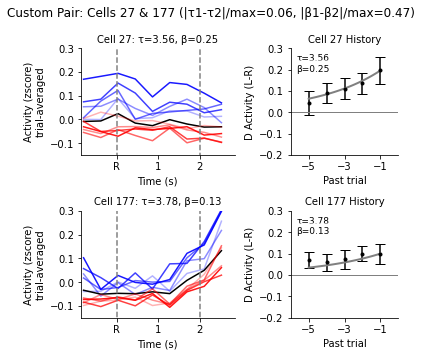

In [5]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import sys
import os
from os.path import dirname, join as pjoin, exists
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

# Add custom module path
sys.path.append('C:\\Users\\Eva\\Desktop\\ImagingCode')
import BD_SciAdv as BD

# Configure matplotlib
plt.rcParams['svg.fonttype'] = 'none'

# Set directories and parameters
save_dir = 'C:\\Users\\Eva\\Desktop\\imaging250629'
sessions_all = ['EZ039_230423']
n_back = 15

# Create directory for saving figures
figure_save_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\3\\example_cells'
os.makedirs(figure_save_dir, exist_ok=True)

def save_figure(fig, filename_base, session=None):
    # Determine save directory
    save_dir = figure_save_dir
    if session:
        # Create session-specific subfolder
        session_dir = pjoin(figure_save_dir, session)
        os.makedirs(session_dir, exist_ok=True)
        save_dir = session_dir
    
    # Create full paths
    png_path = pjoin(save_dir, f"{filename_base}.png")
    svg_path = pjoin(save_dir, f"{filename_base}.svg")
    
    # Save in both formats
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(svg_path, bbox_inches='tight')
#     print(f"Figure saved as {png_path} and {svg_path}")

def beh_exp(x, b, tau, c):
    return b * np.exp(x / tau) + c

def cell_history_activity(neuron_activity, a, a_hist, n_back):
    history_mean = np.zeros(n_back)
    history_std = np.zeros(n_back)
    
    for i in range(n_back):
        # Left trials (a_hist[:, -i-1] == 1)
        left_trials = neuron_activity[a_hist[:, -i-1] == 1]
        # Right trials (a_hist[:, -i-1] == -1)
        right_trials = neuron_activity[a_hist[:, -i-1] == -1]
        
        # Calculate mean difference (Left - Right)
        if len(left_trials) > 0 and len(right_trials) > 0:
            diff = np.mean(left_trials) - np.mean(right_trials)
            # Standard error of the difference
            std_err = np.sqrt(
                np.var(left_trials) / len(left_trials) + 
                np.var(right_trials) / len(right_trials)
            )
            history_mean[i] = diff
            history_std[i] = std_err
    
    return history_mean, history_std

def his_mean_std(ds_2s, output_pd, cell_id, a, a_hist, n_back):
    # Get parameters for this cell - always use loc because cell_id is an index value
    exp_tau = output_pd.loc[cell_id]['tau_RC']
    exp_beta = output_pd.loc[cell_id]['beta_RC']
    
    # x indices for plotting exponential fit
    x_ind = np.arange(-n_back, 0)
    
    # Calculate exponential fit values (not used in this function but included for completeness)
    if exp_beta > 0:
        exp_fit_y = beh_exp(x_ind, 1, exp_tau, 0)
    else:
        exp_fit_y = beh_exp(x_ind, -1, exp_tau, 0)

    # Get neuron activity and calculate history-dependent activity
    # Use isel to match the method used in the activity plots
    neuron_activity = np.array(ds_2s.isel(cell=cell_id).spks)
    history_mean, history_std = cell_history_activity(neuron_activity, a, a_hist, n_back)
    
    return history_mean, history_std, exp_tau

def calculate_history_activity(ds_ready_windowed, cell_pos, a_hist, n_back=5, rc_hist=None):
    # Initialize arrays for results
    history_mean = np.zeros(n_back)
    history_std = np.zeros(n_back)
    
    # Get the cell data
    cell_data = ds_ready_windowed.isel(cell=cell_pos)
    
    # Get frame indices that correspond to the 'R' to '2' time period (0 to 56.66)
    frame_indices = (cell_data.frame >= 0) & (cell_data.frame <= 56.66)
    
    # For each past trial
    for i in range(n_back):
        n = i + 1  # Match the n indexing used in plot_cell_activity
        
        # Left trials (rc_hist[:, -n] == 1)
        left_trials_indices = np.where(rc_hist[:, -n] == 1)[0]
        
        # Right trials (rc_hist[:, -n] == -1)
        right_trials_indices = np.where(rc_hist[:, -n] == -1)[0]
        
        if len(left_trials_indices) > 0 and len(right_trials_indices) > 0:
            # Calculate mean activity for left trials within the frame range
            # First average across the frame range for each trial, then average across trials
            left_activity_by_trial = cell_data.isel(trial=left_trials_indices).where(frame_indices, drop=False)
            left_activity_mean = left_activity_by_trial.mean(dim='frame', skipna=True).mean().values
            
            # Calculate mean activity for right trials within the frame range
            right_activity_by_trial = cell_data.isel(trial=right_trials_indices).where(frame_indices, drop=False)
            right_activity_mean = right_activity_by_trial.mean(dim='frame', skipna=True).mean().values
            
            # Calculate the mean difference (Left - Right)
            diff = left_activity_mean - right_activity_mean
            
            # Calculate standard error of the difference
            left_std = left_activity_by_trial.mean(dim='frame', skipna=True).std().values
            right_std = right_activity_by_trial.mean(dim='frame', skipna=True).std().values
            
            std_err = np.sqrt(
                (left_std**2 / len(left_trials_indices)) + 
                (right_std**2 / len(right_trials_indices))
            )
            
            history_mean[i] = diff
            history_std[i] = std_err
    
    return history_mean, history_std

def load_data():
    """Load and preprocess the data"""
    # Initialize lists
    frac_all_list = []
    
    # Track the current session for figure saving
    global current_session
    current_session = None

    for session in sessions_all:
        mouse = session[:5]
        date = session[6:12]
        print(f'Checking analysis for {mouse} on {date}')
        
        # Set current session for figure saving
        current_session = session

        # Load model output
        output_xarray = xr.open_dataset(pjoin(save_dir, 'cellfits_halves_compare_mdl', 
                                            f'sse_{session}_{n_back}hist_updated.nc'))
        
        # Extract significance criteria
        crit_sig = output_xarray.sel(mdl_type='exp_r', half=0).p_beta_RC < 0.05
        crit_sig_half1 = output_xarray.sel(mdl_type='exp_r', half=1).p_beta_RC < 0.05
        crit_sig_half2 = output_xarray.sel(mdl_type='exp_r', half=2).p_beta_RC < 0.05

        # Convert to dataframes
        out_pd = output_xarray.sel(half=0, mdl_type='exp_r').to_dataframe()[
            ['p_beta_RC', 'beta_RC', 'tau_RC', 'norm_loglik', 'snr']]
        out_pd_half1 = output_xarray.sel(half=1, mdl_type='exp_r').to_dataframe()[
            ['beta_RC', 'tau_RC']]
        out_pd_half2 = output_xarray.sel(half=2, mdl_type='exp_r').to_dataframe()[
            ['beta_RC', 'tau_RC']]
        
        # Add significance flags
        out_pd['crit_sig'] = crit_sig
        out_pd['crit_sig_half1'] = crit_sig_half1
        out_pd['crit_sig_half2'] = crit_sig_half2

        # Filter cells based on criteria
        out_pd2 = out_pd.loc[(out_pd['crit_sig_half1'] == True) & 
                             (out_pd['crit_sig_half2'] == True) & 
                             (out_pd['tau_RC'] < 99.9) & 
                             (out_pd['tau_RC'] >= 0.11), 'tau_RC']
        
        # Calculate fraction of cells meeting criteria
        frac_all = len(out_pd2) / len(out_pd)
        print(f'All_crit= {frac_all}, {len(out_pd2)}, {len(out_pd)}')
        frac_all_list.append(frac_all)

    # Extract modulated cells for further analysis
    modulated_cells = out_pd.loc[(out_pd['crit_sig_half1'] == True) & 
                                 (out_pd['crit_sig_half2'] == True) & 
                                 (out_pd['tau_RC'] < 99.9) & 
                                 (out_pd['tau_RC'] >= 0.11), ['tau_RC', 'beta_RC']]

    # Load neural data
    save_filename = pjoin(save_dir, f'readyaligned\\{sessions_all[0]}_readyaligned.nc')
    ds_ready = xr.open_dataset(save_filename)
    ds_ready_windowed = ds_ready.sel(frame=slice(-28.33, 84.99)).z_spks.coarsen(frame=9, boundary='trim').mean()

    # Prepare choice metrics
    a = np.array(ds_ready.a)
    R = np.array(ds_ready.R)
    a_hist, R_hist, _ = BD.prepare_hist_matrix(a, R, n_back)
    rc_hist = a_hist * R_hist
    
    # Create a mapping from cell indices to positions in the array
    cell_mapping = {}
    for i, cell_id in enumerate(ds_ready_windowed.cell.values):
        cell_mapping[cell_id] = i
    
    # Store this mapping for use in other functions
    global cell_id_to_pos_map
    cell_id_to_pos_map = cell_mapping
    
    return modulated_cells, ds_ready_windowed, rc_hist, out_pd, a, a_hist

def plot_cell_activity(cell_id, ds_ready_windowed, rc_hist, y_lim=[-0.35, 0.35], title_txt=None):
    if title_txt is None:
        title_txt = f'Example cell {cell_id}'
        
    f, ax = plt.subplots(1, 1, figsize=[3.5, 2], tight_layout=True)

    # Plot left reward trials with different trial history
    for i, n in enumerate(range(1, 6)):
        alpha = 0.9 - 0.15 * (i)
        (ds_ready_windowed
            .isel(cell=cell_id, trial=(rc_hist[:, -n] == 1))
            .mean(dim='trial')
        ).plot(ax=ax, c='b', label=f'n={n}, left', alpha=alpha)

    # Plot all trials average
    ds_ready_windowed.isel(cell=cell_id).mean(dim='trial').plot(ax=ax, c='k', label='all trials')

    # Plot right reward trials with different trial history
    for i, n in enumerate(range(1, 6)):
        alpha = 0.9 - 0.15 * (i)
        (ds_ready_windowed
            .isel(cell=cell_id, trial=(rc_hist[:, -n] == -1))
            .mean(dim='trial')
        ).plot(ax=ax, c='r', label=f'n={n}, right', alpha=alpha)

    # Add reference lines and format plot
    ax.plot([0, 0], [-1, 1], '--', c='gray')
    ax.plot([57.66, 57.66], [-1, 1], '--', c='gray')
    ax.set_xlim([-50, 100])
    ax.set_ylim(y_lim)
    ax.set_xticks([28.83, 57.66, 86.49])
    ax.set_xticklabels(['R', 1, 2], fontsize=12)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Activity (zscore) \ntrial-averaged', fontsize=12)
    ax.set_title(title_txt, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Save the figure
    save_figure(f, f"single_cell_{cell_id}", current_session)

    return f, ax

def plot_cell_pairs(modulated_cells, ds_ready_windowed, rc_hist):
    # Create subsets of cells based on tau_RC ranges
    cells_tau_0p5_to_1 = modulated_cells[(modulated_cells['tau_RC'] >= 0.5) & 
                                         (modulated_cells['tau_RC'] <= 1)]
    cells_tau_1_to_2 = modulated_cells[(modulated_cells['tau_RC'] > 1) & 
                                       (modulated_cells['tau_RC'] < 2)]
    cells_tau_2_to_5 = modulated_cells[(modulated_cells['tau_RC'] >= 2) & 
                                       (modulated_cells['tau_RC'] < 5)]

    print(f"Number of cells with 0.5 <= tau <= 1: {len(cells_tau_0p5_to_1)}")
    print(f"Number of cells with 1 < tau < 2: {len(cells_tau_1_to_2)}")
    print(f"Number of cells with 2 <= tau < 5: {len(cells_tau_2_to_5)}")

    # Example of plotting a single cell
    cell_id = 146
    y_lim = [-0.35, 0.35]
    title_txt = 'Example cell 146'
    f, ax = plot_cell_activity(cell_id, ds_ready_windowed, rc_hist, y_lim, title_txt)
    
    # Save the figure
    save_figure(f, f"example_cell_146", current_session)

def find_cell_pairs(modulated_cells):
    # Filter for cells with absolute beta > 0.1
    modulated_cells_filtered = modulated_cells[abs(modulated_cells['beta_RC']) > 0.1]

    # Create subsets of cells based on tau_RC ranges
    cells_tau_0p5_to_1 = modulated_cells_filtered[(modulated_cells_filtered['tau_RC'] >= 0.5) & 
                                                 (modulated_cells_filtered['tau_RC'] <= 1)]
    cells_tau_1_to_2 = modulated_cells_filtered[(modulated_cells_filtered['tau_RC'] > 1) & 
                                               (modulated_cells_filtered['tau_RC'] < 2)]
    cells_tau_2_to_5 = modulated_cells_filtered[(modulated_cells_filtered['tau_RC'] >= 2) & 
                                               (modulated_cells_filtered['tau_RC'] < 5)]

    similar_tau_diff_beta = []
    similar_beta_diff_tau = []

    # Find pairs with similar tau but different beta
    for subset in [cells_tau_0p5_to_1, cells_tau_1_to_2, cells_tau_2_to_5]:
        if len(subset) < 2:
            continue
            
        # Sort by tau_RC
        subset_sorted = subset.sort_values('tau_RC')
        
        # Find pairs with similar tau but different beta
        for i in range(len(subset_sorted) - 1):
            for j in range(i+1, len(subset_sorted)):
                idx1 = subset_sorted.index[i]
                idx2 = subset_sorted.index[j]
                tau1 = subset_sorted.loc[idx1, 'tau_RC']
                tau2 = subset_sorted.loc[idx2, 'tau_RC']
                beta1 = subset_sorted.loc[idx1, 'beta_RC']
                beta2 = subset_sorted.loc[idx2, 'beta_RC']
                
                # If taus are within 10% of each other but betas differ by at least 50%
                if abs(tau1 - tau2) / max(tau1, tau2) < 0.1 and abs(beta1 - beta2) / max(abs(beta1), abs(beta2)) > 0.5:
                    similar_tau_diff_beta.append((idx1, idx2))
                    
    # Find pairs with similar beta but different tau across different tau ranges
    # Cells with 0.5 <= tau <= 1 vs cells with 2 <= tau < 5
    for idx1 in cells_tau_0p5_to_1.index:
        for idx2 in cells_tau_2_to_5.index:
            beta1 = modulated_cells.loc[idx1, 'beta_RC']
            beta2 = modulated_cells.loc[idx2, 'beta_RC']
            
            # Use absolute value of beta for comparison
            abs_beta1 = abs(beta1)
            abs_beta2 = abs(beta2)
            
            # If absolute betas are within 20% of each other
            if abs(abs_beta1 - abs_beta2) / max(abs_beta1, abs_beta2) < 0.2:
                similar_beta_diff_tau.append((idx1, idx2))

    return similar_tau_diff_beta, similar_beta_diff_tau

def plot_cell_pairs_comparison(modulated_cells, ds_ready_windowed, rc_hist, out_pd, a, a_hist):
    # Find cell pairs
    similar_tau_diff_beta, similar_beta_diff_tau = find_cell_pairs(modulated_cells)

    # Plot ALL pairs with similar tau but different beta
    if similar_tau_diff_beta:
        print(f"Found {len(similar_tau_diff_beta)} pairs with similar tau but different beta")
        for i, (idx1, idx2) in enumerate(similar_tau_diff_beta):
            cell1 = idx1
            cell2 = idx2
            tau1 = modulated_cells.loc[cell1, 'tau_RC']
            tau2 = modulated_cells.loc[cell2, 'tau_RC']
            beta1 = modulated_cells.loc[cell1, 'beta_RC']
            beta2 = modulated_cells.loc[cell2, 'beta_RC']
            
            # Get the actual cell IDs from the index of modulated_cells
            actual_cell_id1 = cell1
            actual_cell_id2 = cell2
            
            # Find position of these cells in the arrays
            cell_pos1 = cell_id_to_pos_map.get(actual_cell_id1, None)
            cell_pos2 = cell_id_to_pos_map.get(actual_cell_id2, None)
            
            if cell_pos1 is None or cell_pos2 is None:
                print(f"Warning: Unable to find cells {actual_cell_id1} or {actual_cell_id2} in the dataset")
                continue
            
            # Adjust figure size to make subplots taller and slightly narrower
            fig, axes = plt.subplots(2, 2, figsize=(5.5, 5), tight_layout=True, 
                                    gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 0.7]})
            
            # Plot detailed trial history for both cells (left column)
            for j, (cell_pos, cell_id, ax_row) in enumerate(zip([cell_pos1, cell_pos2], [actual_cell_id1, actual_cell_id2], [axes[0, 0], axes[1, 0]])):
                beta = beta1 if j == 0 else beta2
                tau = tau1 if j == 0 else tau2
                
                # Print debug info
#                 print(f"Pair {i+1}, Cell {j+1}: ID={cell_id}, Position={cell_pos}, tau={tau}, beta={beta}")
                
                # Plot left reward trials with different trial history
                for k, n in enumerate(range(1, 6)):
                    alpha = 0.9 - 0.15 * (k)
                    (ds_ready_windowed
                        .isel(cell=cell_pos, trial=(rc_hist[:, -n] == 1))
                        .mean(dim='trial')
                    ).plot(ax=ax_row, c='b', label=f'n={n}, left', alpha=alpha)
                
                # Plot all trials average
                ds_ready_windowed.isel(cell=cell_pos).mean(dim='trial').plot(ax=ax_row, c='k', label='all trials')
                
                # Plot right reward trials with different trial history
                for k, n in enumerate(range(1, 6)):
                    alpha = 0.9 - 0.15 * (k)
                    (ds_ready_windowed
                        .isel(cell=cell_pos, trial=(rc_hist[:, -n] == -1))
                        .mean(dim='trial')
                    ).plot(ax=ax_row, c='r', label=f'n={n}, right', alpha=alpha)
                
                # Determine data range for this cell
                cell_data = ds_ready_windowed.isel(cell=cell_pos)
                y_min = cell_data.min().values
                y_max = cell_data.max().values
                padding = 0.1 * (y_max - y_min)  # 10% padding
                
                # Add reference lines and format plot
                ax_row.plot([0, 0], [-1, 1], '--', c='gray')
                ax_row.plot([57.66, 57.66], [-1, 1], '--', c='gray')
                ax_row.set_xlim([-25, 82]) 
                # Set consistent y-limits for all cells
                ax_row.set_ylim([-0.4, 0.4])
                ax_row.autoscale(False)  # Prevent automatic rescaling
                ax_row.set_xticks([0, 28.83, 57.66])
                ax_row.set_xticklabels(['R', 1, 2], fontsize=10)
                ax_row.set_xlabel('Time (s)', fontsize=10)
                ax_row.set_ylabel('Activity (zscore)\ntrial-averaged', fontsize=10)
                ax_row.set_title(f'Cell {cell_id}: τ={tau:.2f}, β={beta:.2f}', fontsize=10)
                ax_row.spines['top'].set_visible(False)
                ax_row.spines['right'].set_visible(False)
                
                # Remove legend
                if ax_row.get_legend() is not None:
                    ax_row.get_legend().remove()
                
                # Plot historical analysis (right column)
                ax_hist = axes[j, 1]
                
                # Calculate history activity using mean between R and 2 (0 and 57.66)
                # Use only the most recent 5 trials instead of 10
                history_mean, history_std = calculate_history_activity(ds_ready_windowed, cell_pos, a_hist, n_back=5, rc_hist=rc_hist)
                
                # Create x values for past trials correctly (most recent should be at x=-1)
                x_vals = np.arange(-1, -6, -1)
                
                # Plot horizontal zero line - extended to match new xlim
                ax_hist.plot([-6, 0], [0, 0], '-', color=[.5, .5, .5], linewidth=1, label='_nolegend_')
                
                # Plot error bars with corrected x values
                ax_hist.errorbar(x_vals, history_mean, yerr=history_std, fmt='.k', 
                                 linestyle='none', capsize=5)
                
                # Create x values for exponential fit (more points for smoother curve)
                x_fit = np.linspace(-5, -1, 100)
                
                # Get tau and beta values from the modulated_cells dataframe
                exp_tau = tau  # Use tau directly from the current cell
                exp_beta = beta  # Use beta directly from the current cell
                
                # Calculate and plot exponential fit using actual parameters
                # Scale the exponential fit to match data magnitude 
                max_hist_val = np.max(np.abs(history_mean))
                scale_factor = max_hist_val / np.max(np.abs(beh_exp(x_fit, 1, exp_tau, 0)))
                
                # Plot the fit in grey regardless of beta sign
                if exp_beta > 0:
                    y_fit = beh_exp(x_fit, scale_factor, exp_tau, 0)
                else:
                    y_fit = beh_exp(x_fit, -scale_factor, exp_tau, 0)
                
                # Use grey color for exponential fit
                ax_hist.plot(x_fit, y_fit, '-', color='grey', linewidth=2)
                
                # Add tau value to the plot
                ax_hist.text(0.05, 0.95, f'τ={exp_tau:.2f}', transform=ax_hist.transAxes, 
                            fontsize=9, va='top', ha='left', 
                            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
                
                # Format plot with updated xlim for -5 to -1 range
                ax_hist.set_xlim([-6, 0])  # Updated xlim
                ax_hist.set_xticks([-1, -3, -5])  # Updated xticks
                ax_hist.set_ylabel('D Activity (L-R)', fontsize=10)
                ax_hist.set_xlabel('Past trial', fontsize=10)
                ax_hist.set_title(f'Cell {cell_id} History', fontsize=10)
                ax_hist.spines['top'].set_visible(False)
                ax_hist.spines['right'].set_visible(False)
                
                # Remove legend if it exists
                if ax_hist.get_legend() is not None:
                    ax_hist.get_legend().remove()
            
            # No legend for any plot
            
            fig.suptitle(f'Pair {i+1}: Similar tau (~{(tau1+tau2)/2:.2f}), Different beta values', fontsize=12)
            plt.tight_layout()
            
            # Save the figure
            save_figure(fig, f"similar_tau_diff_beta_pair_{i+1}", current_session)
    else:
        print("No pairs found with similar tau but different beta")

    # Plot ALL pairs with similar beta but different tau
    if similar_beta_diff_tau:
        print(f"Found {len(similar_beta_diff_tau)} pairs with similar beta but different tau")
        for i, (idx1, idx2) in enumerate(similar_beta_diff_tau):
            cell1 = idx1
            cell2 = idx2
            tau1 = modulated_cells.loc[cell1, 'tau_RC']
            tau2 = modulated_cells.loc[cell2, 'tau_RC']
            beta1 = modulated_cells.loc[cell1, 'beta_RC']
            beta2 = modulated_cells.loc[cell2, 'beta_RC']
            
            # Get the actual cell IDs from the index of modulated_cells
            actual_cell_id1 = cell1
            actual_cell_id2 = cell2
            
            # Find position of these cells in the arrays
            cell_pos1 = cell_id_to_pos_map.get(actual_cell_id1, None)
            cell_pos2 = cell_id_to_pos_map.get(actual_cell_id2, None)
            
            if cell_pos1 is None or cell_pos2 is None:
                print(f"Warning: Unable to find cells {actual_cell_id1} or {actual_cell_id2} in the dataset")
                continue
            
            # Adjust figure size to make subplots taller and slightly narrower
            fig, axes = plt.subplots(2, 2, figsize=(5.5, 5), tight_layout=True, 
                                    gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 0.7]})
            
            # Plot detailed trial history for both cells (left column)
            for j, (cell_pos, cell_id, ax_row) in enumerate(zip([cell_pos1, cell_pos2], [actual_cell_id1, actual_cell_id2], [axes[0, 0], axes[1, 0]])):
                beta = beta1 if j == 0 else beta2
                tau = tau1 if j == 0 else tau2
                
                # Print debug info
#                 print(f"Pair {i+1}, Cell {j+1}: ID={cell_id}, Position={cell_pos}, tau={tau}, beta={beta}")
                
                # Plot left reward trials with different trial history
                for k, n in enumerate(range(1, 6)):
                    alpha = 0.9 - 0.15 * (k)
                    (ds_ready_windowed
                        .isel(cell=cell_pos, trial=(rc_hist[:, -n] == 1))
                        .mean(dim='trial')
                    ).plot(ax=ax_row, c='b', label=f'n={n}, left', alpha=alpha)
                
                # Plot all trials average
                ds_ready_windowed.isel(cell=cell_pos).mean(dim='trial').plot(ax=ax_row, c='k', label='all trials')
                
                # Plot right reward trials with different trial history
                for k, n in enumerate(range(1, 6)):
                    alpha = 0.9 - 0.15 * (k)
                    (ds_ready_windowed
                        .isel(cell=cell_pos, trial=(rc_hist[:, -n] == -1))
                        .mean(dim='trial')
                    ).plot(ax=ax_row, c='r', label=f'n={n}, right', alpha=alpha)
                
                # Determine data range for this cell
                cell_data = ds_ready_windowed.isel(cell=cell_pos)
                y_min = cell_data.min().values
                y_max = cell_data.max().values
                padding = 0.1 * (y_max - y_min)  # 10% padding
                
                # Add reference lines and format plot
                ax_row.plot([0, 0], [-1, 1], '--', c='gray')
                ax_row.plot([57.66, 57.66], [-1, 1], '--', c='gray')
                ax_row.set_xlim([-25, 82])
                # Set consistent y-limits for all cells
                ax_row.set_ylim([-0.4, 0.4])
                ax_row.autoscale(False)  # Prevent automatic rescaling
                ax_row.set_xticks([0, 28.83, 57.66])
                ax_row.set_xticklabels(['R', 1, 2], fontsize=10)
                ax_row.set_xlabel('Time (s)', fontsize=10)
                ax_row.set_ylabel('Activity (zscore)\ntrial-averaged', fontsize=10)
                ax_row.set_title(f'Cell {cell_id}: τ={tau:.2f}, β={beta:.2f}', fontsize=10)
                ax_row.spines['top'].set_visible(False)
                ax_row.spines['right'].set_visible(False)
                
                # Remove legend
                if ax_row.get_legend() is not None:
                    ax_row.get_legend().remove()
                
                # Plot historical analysis (right column)
                ax_hist = axes[j, 1]
                
                # Calculate history activity using mean between R and 2 (0 and 57.66)
                # Use only the most recent 5 trials instead of 10
                history_mean, history_std = calculate_history_activity(ds_ready_windowed, cell_pos, a_hist, n_back=5, rc_hist=rc_hist)
                
                # Create x values for past trials correctly (most recent should be at x=-1)
                x_vals = np.arange(-1, -6, -1)
                
                # Plot horizontal zero line - extended to match new xlim
                ax_hist.plot([-6, 0], [0, 0], '-', color=[.5, .5, .5], linewidth=1, label='_nolegend_')
                
                # Plot error bars with corrected x values
                ax_hist.errorbar(x_vals, history_mean, yerr=history_std, fmt='.k', 
                                 linestyle='none', capsize=5)
                
                # Create x values for exponential fit (more points for smoother curve)
                x_fit = np.linspace(-5, -1, 100)
                
                # Get tau and beta values from the modulated_cells dataframe
                exp_tau = tau  # Use tau directly from the current cell
                exp_beta = beta  # Use beta directly from the current cell
                
                # Calculate and plot exponential fit using actual parameters
                # Scale the exponential fit to match data magnitude 
                max_hist_val = np.max(np.abs(history_mean))
                scale_factor = max_hist_val / np.max(np.abs(beh_exp(x_fit, 1, exp_tau, 0)))
                
                # Plot the fit in grey regardless of beta sign
                if exp_beta > 0:
                    y_fit = beh_exp(x_fit, scale_factor, exp_tau, 0)
                else:
                    y_fit = beh_exp(x_fit, -scale_factor, exp_tau, 0)
                
                # Use grey color for exponential fit
                ax_hist.plot(x_fit, y_fit, '-', color='grey', linewidth=2)
                
                # Add tau value to the plot
                ax_hist.text(0.05, 0.95, f'τ={exp_tau:.2f}', transform=ax_hist.transAxes, 
                            fontsize=9, va='top', ha='left', 
                            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
                
                # Format plot with updated xlim for -5 to -1 range
                ax_hist.set_xlim([-6, 0])  # Updated xlim
                ax_hist.set_xticks([-1, -3, -5])  # Updated xticks
                ax_hist.set_ylabel('D Activity (L-R)', fontsize=10)
                ax_hist.set_xlabel('Past trial', fontsize=10)
                ax_hist.set_title(f'Cell {cell_id} History', fontsize=10)
                ax_hist.spines['top'].set_visible(False)
                ax_hist.spines['right'].set_visible(False)
                
                # Remove legend if it exists
                if ax_hist.get_legend() is not None:
                    ax_hist.get_legend().remove()
            
            # No legend for any plot
            
            fig.suptitle(f'Pair {i+1}: Similar beta (~{(beta1+beta2)/2:.2f}), Different tau values', fontsize=12)
            plt.tight_layout()
            
            # Save the figure
            save_figure(fig, f"similar_beta_diff_tau_pair_{i+1}", current_session)
    else:
        print("No pairs found with similar beta but different tau")

def plot_specific_cell_pair(cell_id1, cell_id2, ds_ready_windowed, rc_hist, out_pd, a, a_hist, session=None, 
                           activity_ylim=None, history_ylim=None, frame_coarsen=None):
    if frame_coarsen is not None:
        # Get the original dataset
        save_filename = pjoin(save_dir, f'readyaligned\\{sessions_all[0]}_readyaligned.nc')
        ds_ready = xr.open_dataset(save_filename)
        # Recompute windowed data with the specified coarsening
        ds_ready_windowed_custom = ds_ready.sel(frame=slice(-28.83, 86.49)).z_spks.coarsen(frame=frame_coarsen, boundary='trim').mean()
        # Use this custom windowed data for the plot
        plot_data = ds_ready_windowed_custom
    else:
        # Use the provided windowed data
        plot_data = ds_ready_windowed

    # Check if the cells exist in the dataset
    cell_mapping = {}
    for i, cell_id in enumerate(plot_data.cell.values):
        cell_mapping[cell_id] = i
        
    if cell_id1 not in cell_mapping or cell_id2 not in cell_mapping:
        missing_cells = []
        if cell_id1 not in cell_mapping:
            missing_cells.append(str(cell_id1))
        if cell_id2 not in cell_mapping:
            missing_cells.append(str(cell_id2))
        print(f"Error: Cell ID(s) {', '.join(missing_cells)} not found in the dataset.")
        return
    
    # Check if the cells have model parameters in out_pd
    if cell_id1 not in out_pd.index or cell_id2 not in out_pd.index:
        missing_params = []
        if cell_id1 not in out_pd.index:
            missing_params.append(str(cell_id1))
        if cell_id2 not in out_pd.index:
            missing_params.append(str(cell_id2))
        print(f"Error: No model parameters found for cell ID(s) {', '.join(missing_params)}.")
        return
    
    # Get tau and beta values for each cell
    tau1 = out_pd.loc[cell_id1]['tau_RC']
    tau2 = out_pd.loc[cell_id2]['tau_RC']
    beta1 = out_pd.loc[cell_id1]['beta_RC']
    beta2 = out_pd.loc[cell_id2]['beta_RC']
    
    # Get cell positions in the array
    cell_pos1 = cell_mapping[cell_id1]
    cell_pos2 = cell_mapping[cell_id2]
    
    # Determine what kind of pair this is (similar tau or similar beta)
    abs_beta1 = abs(beta1)
    abs_beta2 = abs(beta2)
    beta_diff_pct = abs(abs_beta1 - abs_beta2) / max(abs_beta1, abs_beta2)
    tau_diff_pct = abs(tau1 - tau2) / max(tau1, tau2)
    
    pair_type = "Custom"
    if tau_diff_pct < 0.1 and beta_diff_pct > 0.5:
        pair_type = "Similar Tau, Different Beta"
    elif beta_diff_pct < 0.2 and tau_diff_pct > 0.5:
        pair_type = "Similar Beta, Different Tau"
    
    # Create the figure
    fig, axes = plt.subplots(2, 2, figsize=(5.5, 5), tight_layout=True, 
                            gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 0.7]})
    
    # Plot detailed trial history for both cells (left column)
    for j, (cell_pos, cell_id, ax_row) in enumerate(zip([cell_pos1, cell_pos2], [cell_id1, cell_id2], [axes[0, 0], axes[1, 0]])):
        beta = beta1 if j == 0 else beta2
        tau = tau1 if j == 0 else tau2
        
        # Plot left reward trials with different trial history
        for k, n in enumerate(range(1, 6)):
            alpha = 0.9 - 0.15 * (k)
            (plot_data
                .isel(cell=cell_pos, trial=(rc_hist[:, -n] == 1))
                .mean(dim='trial')
            ).plot(ax=ax_row, c='b', label=f'n={n}, left', alpha=alpha)
        
        # Plot all trials average
        plot_data.isel(cell=cell_pos).mean(dim='trial').plot(ax=ax_row, c='k', label='all trials')
        
        # Plot right reward trials with different trial history
        for k, n in enumerate(range(1, 6)):
            alpha = 0.9 - 0.15 * (k)
            (plot_data
                .isel(cell=cell_pos, trial=(rc_hist[:, -n] == -1))
                .mean(dim='trial')
            ).plot(ax=ax_row, c='r', label=f'n={n}, right', alpha=alpha)
        
        # Add reference lines and format plot
        ax_row.plot([0, 0], [-1, 1], '--', c='gray')
        ax_row.plot([57.66, 57.66], [-1, 1], '--', c='gray')
        ax_row.set_xlim([-25, 82]) 
        
        # Set y-limits for activity plot
        if activity_ylim is not None:
            ax_row.set_ylim(activity_ylim)
            ax_row.autoscale(False)  # Prevent automatic rescaling
        else:
            ax_row.set_ylim([-0.4, 0.4])
            ax_row.autoscale(False)  # Prevent automatic rescaling
            
        ax_row.set_xticks([0, 28.83, 57.66])
        ax_row.set_xticklabels(['R', 1, 2], fontsize=10)
        ax_row.set_xlabel('Time (s)', fontsize=10)
        ax_row.set_ylabel('Activity (zscore)\ntrial-averaged', fontsize=10)
        ax_row.set_title(f'Cell {cell_id}: τ={tau:.2f}, β={beta:.2f}', fontsize=10)
        ax_row.spines['top'].set_visible(False)
        ax_row.spines['right'].set_visible(False)
        
        # Remove legend
        if ax_row.get_legend() is not None:
            ax_row.get_legend().remove()
        
        # Plot historical analysis (right column)
        ax_hist = axes[j, 1]
        
        # Calculate history activity using mean between R and 2 (0 and 57.66)
        # Use only the most recent 5 trials
        history_mean, history_std = calculate_history_activity(plot_data, cell_pos, a_hist, n_back=5, rc_hist=rc_hist)
        
        # Create x values for past trials (most recent should be at x=-1)
        x_vals = np.arange(-1, -6, -1)
        
        # Plot horizontal zero line
        ax_hist.plot([-6, 0], [0, 0], '-', color=[.5, .5, .5], linewidth=1, label='_nolegend_')
        
        # Plot error bars with corrected x values
        ax_hist.errorbar(x_vals, history_mean, yerr=history_std, fmt='.k', 
                         linestyle='none', capsize=5)
        
        # Create x values for exponential fit (more points for smoother curve)
        x_fit = np.linspace(-5, -1, 100)
        
        # Get tau and beta values from the out_pd dataframe
        exp_tau = tau  # Use tau directly from the current cell
        exp_beta = beta  # Use beta directly from the current cell
        
        # Calculate and plot exponential fit using actual parameters
        # Scale the exponential fit to match data magnitude 
        max_hist_val = np.max(np.abs(history_mean))
        scale_factor = max_hist_val / np.max(np.abs(beh_exp(x_fit, 1, exp_tau, 0)))
        
        # Plot the fit in grey regardless of beta sign
        if exp_beta > 0:
            y_fit = beh_exp(x_fit, scale_factor, exp_tau, 0)
        else:
            y_fit = beh_exp(x_fit, -scale_factor, exp_tau, 0)
        
        # Use grey color for exponential fit
        ax_hist.plot(x_fit, y_fit, '-', color='grey', linewidth=2)
        
        # Add tau and beta values to the plot
        ax_hist.text(0.05, 0.95, f'τ={exp_tau:.2f}', transform=ax_hist.transAxes, 
                    fontsize=9, va='top', ha='left', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        ax_hist.text(0.05, 0.85, f'β={exp_beta:.2f}', transform=ax_hist.transAxes, 
                    fontsize=9, va='top', ha='left', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        
        # Format plot with updated xlim
        ax_hist.set_xlim([-6, 0])
        
        # Set y-axis limits for history plot
        if history_ylim is not None:
            ax_hist.set_ylim(history_ylim)
            ax_hist.autoscale(False)  # Prevent automatic rescaling
            
        ax_hist.set_xticks([-1, -3, -5])
        ax_hist.set_ylabel('D Activity (L-R)', fontsize=10)
        ax_hist.set_xlabel('Past trial', fontsize=10)
        ax_hist.set_title(f'Cell {cell_id} History', fontsize=10)
        ax_hist.spines['top'].set_visible(False)
        ax_hist.spines['right'].set_visible(False)
        
        # Remove legend if it exists
        if ax_hist.get_legend() is not None:
            ax_hist.get_legend().remove()
    
    # Set title for the entire figure
    fig.suptitle(f'{pair_type} Pair: Cells {cell_id1} & {cell_id2} (|τ1-τ2|/max={tau_diff_pct:.2f}, |β1-β2|/max={beta_diff_pct:.2f})', 
                fontsize=12)
    plt.tight_layout()
    
    # Save the figure
    if session is None:
        session = current_session
    
    save_figure(fig, f"custom_pair_cells_{cell_id1}_{cell_id2}", session)
    
    return fig, axes

if __name__ == "__main__":
    # Load data and create modulated cells
    modulated_cells, ds_ready_windowed, rc_hist, out_pd, a, a_hist = load_data()

    # Filter for cells with beta > 0.1
    modulated_cells_filtered = modulated_cells[abs(modulated_cells['beta_RC']) > 0.1]

    # Create subsets of cells based on tau_RC ranges with beta > 0.1
    cells_tau_0p5_to_1 = modulated_cells_filtered[(modulated_cells_filtered['tau_RC'] >= 0.5) & 
                                        (modulated_cells_filtered['tau_RC'] <= 1)]
    cells_tau_1_to_2 = modulated_cells_filtered[(modulated_cells_filtered['tau_RC'] > 1) & 
                                    (modulated_cells_filtered['tau_RC'] < 2)]
    cells_tau_2_to_5 = modulated_cells_filtered[(modulated_cells_filtered['tau_RC'] >= 2) & 
                                    (modulated_cells_filtered['tau_RC'] < 5)]

    print(f"Number of cells with |beta| > 0.1: {len(modulated_cells_filtered)} out of {len(modulated_cells)}")
    print(f"Number of cells with 0.5 <= tau <= 1 and |beta| > 0.1: {len(cells_tau_0p5_to_1)}")
    print(f"Number of cells with 1 < tau < 2 and |beta| > 0.1: {len(cells_tau_1_to_2)}")
    print(f"Number of cells with 2 <= tau < 5 and |beta| > 0.1: {len(cells_tau_2_to_5)}")

    # Plot cell pairs for comparison
#     plot_cell_pairs_comparison(modulated_cells_filtered, ds_ready_windowed, rc_hist, out_pd, a, a_hist)
    
    # Example with custom parameters
    plot_specific_cell_pair(27, 177, ds_ready_windowed, rc_hist, out_pd, a, a_hist, 
                        activity_ylim=[-0.15, 0.3], history_ylim=[-0.2, 0.3], frame_coarsen=12)